### colab installs

In [15]:
import sys

In [16]:
if 'google.colab' in sys.modules:
    !pip install torch
    !pip install scikit-learn
    !pip install matplotlib as plt, pandas as pd

# Imports

In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

import torch                                                                              
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# Data loading

In [2]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


There are 166 features to the dataset, 92 local and 74 aggregated. [add source - demistifying... ]
The CSV does not have the columns defined
txid - transaction id
time_step - 1-49 timestamps groups
lf_{number} - local feature number 1-92
af_{number} - aggregated feature number 1-74


In [3]:
cols = ['txId','time_step']


local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols

In [4]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [ ]:
# map classes: original licit: 2, original illicit: 1, unknown. 

class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True)


In [6]:
df = pd.merge(features, classes, on='txId')

## Graph Feature Enrichment

In [7]:
# feature enrichment - add edges
def add_graph_features(target_df, input_edges):                                           
      node_ids = set(target_df['txId'])                                                   

        # select only edgest in in- and out- ids                                                                                   
      relevant_edges = input_edges[                                                         
          input_edges['txId1'].isin(node_ids) &                                             
          input_edges['txId2'].isin(node_ids)                                               
      ]                                                                                     
                                                                                            
      G = nx.from_pandas_edgelist(relevant_edges, 'txId1', 'txId2',                         
                                   create_using=nx.DiGraph())                               
                                                                                            
      # directed degree                                                                     
      in_degree  = dict(G.in_degree())      # directed degree in                                                
      out_degree = dict(G.out_degree())                      # out                            
      clustering = nx.clustering(G.to_undirected())    # clustering coefficient                                       
      pagerank = nx.pagerank(G, alpha=0.85)   

      idx = target_df['txId']
      new_cols_df = target_df.assign(
            in_degree = idx.map(lambda x: in_degree.get(x, 0)),
            out_degree= idx.map(lambda x: out_degree.get(x, 0)),
            degree_ratio=  idx.map(lambda x: in_degree.get(x, 0) / (out_degree.get(x, 0) + 1e-9)),
            clustering_coef= idx.map(lambda x: clustering.get(x, 0)),
            pagerank= idx.map(lambda x: pagerank.get(x, 0)),
            )

                                                                                          
      return new_cols_df
#pd.concat([target_df, new_cols_df], axis=1) 


In [8]:
enriched_df = add_graph_features(df, edges)

/tmp/ipykernel_28640/1227313737.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_cols_df = target_df.assign(


In [9]:
enriched_df.shape

(203769, 173)

In [ ]:
train_df = df[(df['class'] == 0) & (df['time_step'] <= 40)].copy()
test_df = df[df['time_step'] > 40].copy()


In [12]:
#TODO: set embedding of node id

train on licit class 0
training set: time-step 1-30
val: 31-49

In [13]:
## TODO: add embeddings for the connecting transactions. 

In [14]:
# Identify feature columns (excluding metadata)
metadata_cols = ['txId', 'time_step', 'class']

X_train_raw = train_df.drop(columns=metadata_cols)
X_test_raw = test_df.drop(columns=metadata_cols)


# Simple Autoencoder

justification : 
  it tests whether non-linearity alone (same reconstruction principle as NMF/TSVD) is       
  sufficient to separate fraud from licit

* metrics for reconstruction error: https://www.shadecoder.com/de/topics/reconstruction-error-a-comprehensive-guide-for-2025

## pipeline definition

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [49]:
class Autoencoder(nn.Module):
    """ an autoencoder model with 2 layers"""
    def __init__(self, input_dim, hidden_dim=128, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
            # no output activation — StandardScaled data can be negative
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


In [54]:
def scaler_pipeline(X_train, X_test, feature_cols, graph_cols=None):
    scaler_features = StandardScaler()

    if graph_cols:                                                             
        scaler_graph    = RobustScaler()
        X_train_scaled = np.hstack([
            scaler_features.fit_transform(X_train[feature_cols]),                                
            scaler_graph.fit_transform(X_train[graph_cols])                                      
        ])
        X_test_scaled = np.hstack([                                                               
            scaler_features.transform(X_test[feature_cols]),
            scaler_graph.transform(X_test[graph_cols])
        ])   
        
    else: 
        X_train_scaled = scaler_features.fit_transform(X_train[feature_cols])                                
        X_test_scaled = scaler_features.transform(X_test[feature_cols])                                                                                     

    return X_train_scaled, X_test_scaled

In [57]:
def train_autoencoder(X_train, hidden_dim=64, latent_dim=16, epochs=50, batch_size=256, lr=1e-3):
    model = Autoencoder(X_train.shape[1], hidden_dim, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_train)), batch_size=batch_size, shuffle=True)
    model.train()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)
        losses.append(epoch_loss / len(X_train))
    return model, losses


def score_autoencoder(model, X_test):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test)
        errors = torch.mean((X_t - model(X_t)) ** 2, dim=1).numpy()
    return errors
  

def ae_orchestrator(X_train, X_test, test_df, feature_cols, graph_cols=None, hidden_dim=64, latent_dim=16, epochs=50, batch_size=256, lr=1e-3):
    # X_train = np.array(X_train)
    # X_test  = np.array(X_test)

    # scaler = StandardScaler()
    # X_train_s = scaler.fit_transform(X_train)
    # X_test_s  = scaler.transform(X_test)
    X_train_scaled, X_test_scaled = scaler_pipeline(X_train, X_test, feature_cols, graph_cols)

    model, losses = train_autoencoder(X_train_scaled, hidden_dim, latent_dim,
                                        epochs, batch_size, lr)
    errors = score_autoencoder(model, X_test_scaled)

    test_results = pd.DataFrame({
        'txId':          test_df['txId'].values,
        'time_step':     test_df['time_step'].values,
        'class':         test_df['class'].values,
        'anomaly_score': errors
    })
    labeled = test_results[test_results['class'] < 2]
    auc = roc_auc_score(labeled['class'].astype(int), labeled['anomaly_score'])
    ap  = average_precision_score(labeled['class'].astype(int), labeled['anomaly_score'])
    print(f'ROC-AUC: {auc:.4f} | AP: {ap:.4f}')
    print(labeled.groupby('class')['anomaly_score'].describe())
    return model, losses, test_results, auc, ap

    


In [ ]:
def plot_ae_latent_comparison(metrics_df, latent_dims, results):

    fig, axes = plt.subplots(1 + len(latent_dims), 1, figsize=(10, 4 * (1 + len(latent_dims))))

    # top: AUC and AP across latent dims
    ax = axes[0]
    x = range(len(latent_dims))
    ax.plot(x, metrics_df['auc'], marker='o', label='ROC-AUC', color='steelblue')
    ax.plot(x, metrics_df['ap'],  marker='o', label='AP',       color='crimson')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='random')
    ax.set_xticks(x)
    ax.set_xticklabels([f'ld={d}' for d in latent_dims])
    ax.set_ylabel('Score')
    ax.set_title('AUC / AP by latent dimension')
    ax.legend()

    # one boxplot per latent_dim — anomaly score distribution by class
    for i, ld in enumerate(latent_dims):
        ax = axes[i + 1]
        labeled = results[ld]['test_results'][results[ld]['test_results']['class'] < 2]
        labeled.boxplot(column='anomaly_score', by='class', ax=ax)
        ax.set_title(f'latent_dim={ld}  |  AUC={metrics_df.loc[i,"auc"]:.3f} | AP={metrics_df.loc[i,"ap"]:.3f}')
        ax.set_xlabel('Class (0=licit, 1=illicit)')
        ax.set_ylabel('Reconstruction error')

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

    return results, metrics_df

## Training and eval

In [59]:
feature_cols = local_cols + agg_cols   # lf_* and af_* only   
                                                                                            
model, losses, test_results, auc, ap = ae_orchestrator(
    train_df[feature_cols],                                                               
    test_df[feature_cols],
    test_df,
    feature_cols,
    hidden_dim=64, latent_dim=16, epochs=50
    ) 

ROC-AUC: 0.3443 | AP: 0.0368
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      9449.0  0.226332  1.322093  0.010277  0.068647  0.113318  0.202545   
1       524.0  0.114318  0.237119  0.007692  0.044484  0.073942  0.128210   

              max  
class              
0      108.428932  
1        5.024789  


dimensions: 30
ROC-AUC: 0.3094 | AP: 0.0352
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      9449.0  0.241151  1.931955  0.010252  0.066144  0.107108  0.190151   
1       524.0  0.105267  0.245512  0.010122  0.033960  0.060204  0.114246   

             max  
class             
0      98.668602  
1       5.177342  
dimensions: 70
ROC-AUC: 0.3265 | AP: 0.0361
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      9449.0  0.183506  1.120640  0.009589  0.053567  0.087199  0.154073   
1       524.0  0.091575  0.248525  0.007136  0.030654  0.048915  0.092467   

             max  
class             
0      65.275803  
1       5.383063  
dimensions: 100
ROC-AUC: 0.2979 | AP: 0.0348
        count      mean       std       min       25%       50%       75%  \
class               

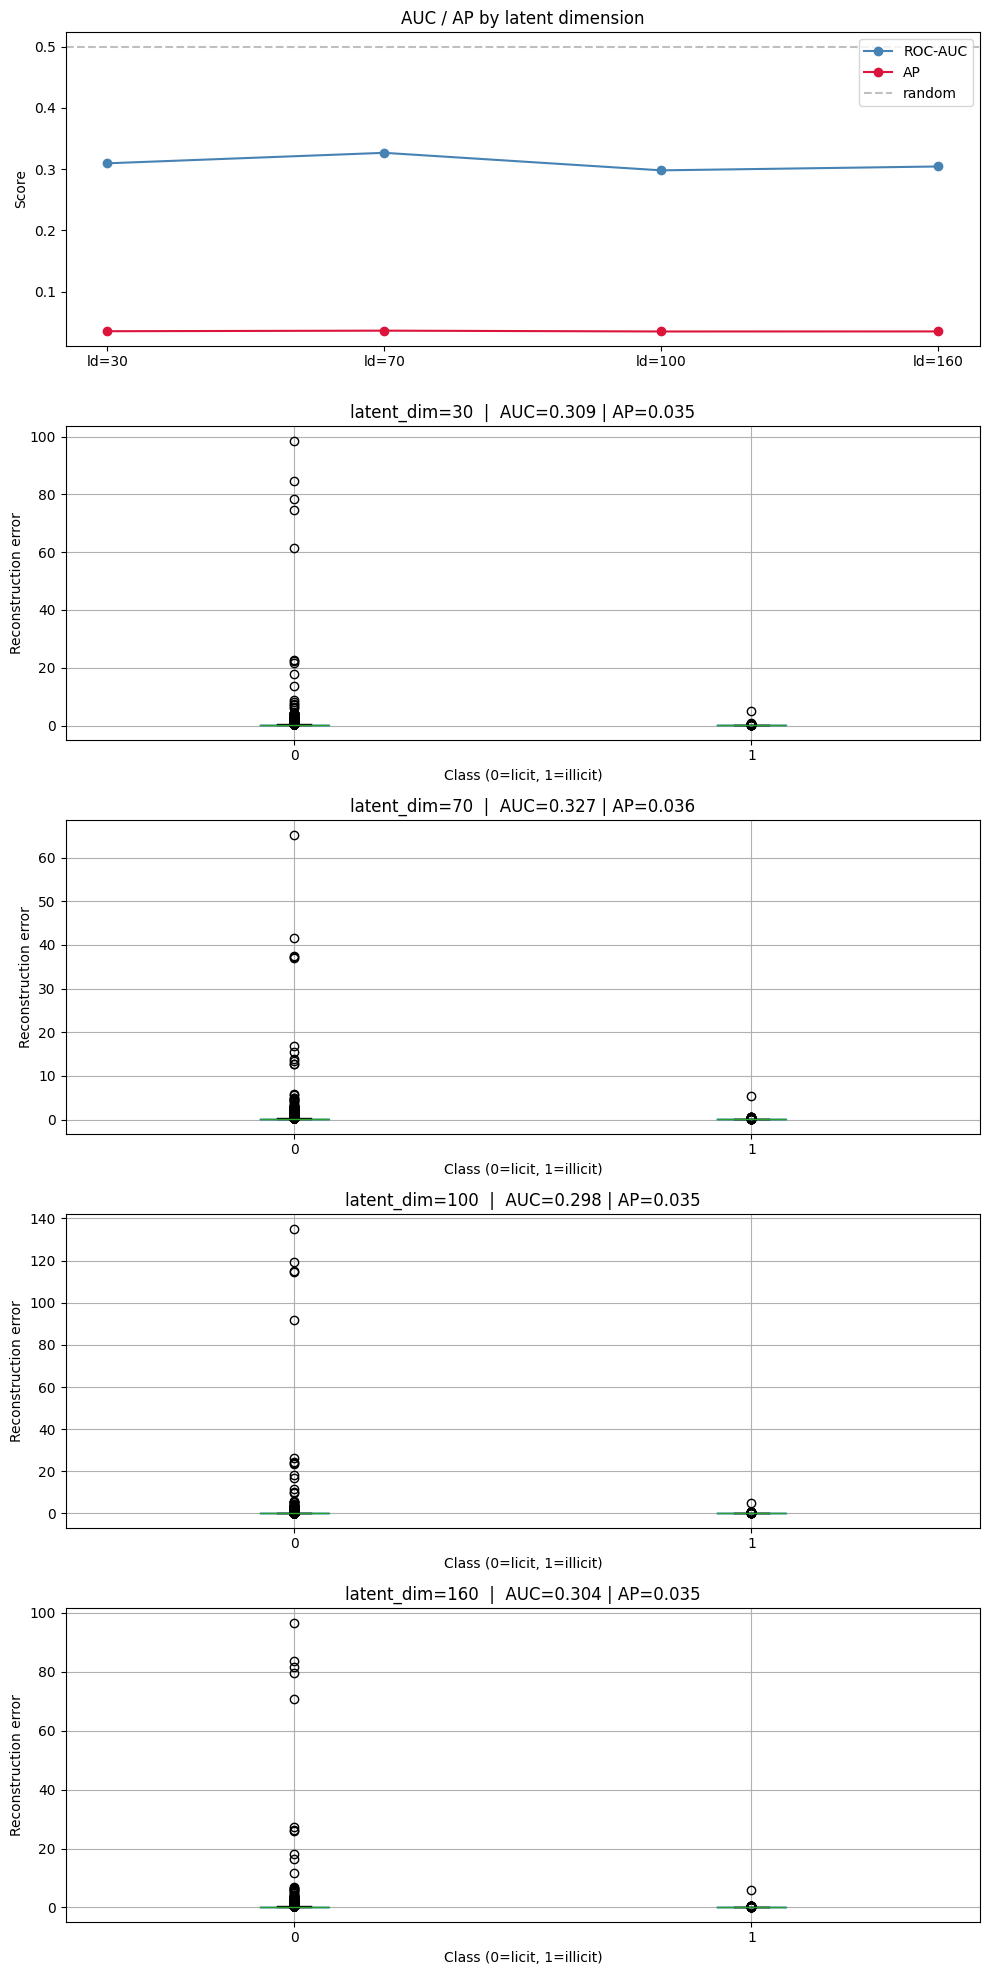

({30: {'test_results':             txId  time_step class  anomaly_score
   0       12781680         41     0       0.863419
   1       39010634         41     2       0.094686
   2       12688678         41     0       0.099447
   3       12688662         41     2       0.051300
   4       12803377         41     2       0.053349
   ...          ...        ...   ...            ...
   42161  173077460         49     2       0.036733
   42162  158577750         49     2       0.102504
   42163  158375402         49     1       0.153355
   42164  158654197         49     2       0.035953
   42165  157597225         49     2       0.066953
   
   [42166 rows x 4 columns],
   'losses': [0.8314689700025922,
    0.6084071496567333,
    0.5128107912122453,
    0.4603784713160966,
    0.4133229531830427,
    0.39794298438232373,
    0.3600596762889362,
    0.34376619971709854,
    0.3138386628389505,
    0.30403868581826315,
    0.34769407051507045,
    0.29104047075055806,
    0.29569909805383

In [64]:
ld = [30, 70, 100, 160]

results = {}
metrics = []
for dim in ld:
    print(f'dimensions: {dim}')
    model, losses, test_results, auc, ap = ae_orchestrator(
    train_df[feature_cols],
    test_df[feature_cols],
    test_df,
    feature_cols,
    hidden_dim=64, latent_dim=dim, epochs=50
    ) 

    results[dim] = {'test_results': test_results, 'losses': losses}
    metrics.append({'latent_dim': dim, 'auc': auc, 'ap': ap})

metrics_df = pd.DataFrame(metrics)

plot_ae_latent_comparison(metrics_df, ld, results)

conclusion: also in advanced architecture - 4 layers, higher ld and large layer size, the reconstruction error for class 0 remains with mean larger than that for class 1. 

## Using enriched graph features: 

In [66]:
enriched_df = add_graph_features(df, edges)
e_train_df = enriched_df[(enriched_df['class'] == 0) & (enriched_df['time_step'] <= 40)].copy()
e_test_df = enriched_df[enriched_df['time_step'] > 40].copy()

graph_cols = ['in_degree', 'out_degree', 'degree_ratio', 'clustering_coef', 'pagerank'] 
# graph_scaler = RobustScaler() 
# e_train_df[graph_cols] = graph_scaler.fit_transform(e_train_df[graph_cols])                   
# e_test_df[graph_cols]  = graph_scaler.transform(e_test_df[graph_cols]) 

enriched_cols = feature_cols + graph_cols


/tmp/ipykernel_28640/1227313737.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_cols_df = target_df.assign(


dimensions: 30
ROC-AUC: 0.4563 | AP: 0.0527
        count         mean           std       min       25%       50%  \
class                                                                    
0      9449.0  4284.887695  82988.015625  0.117792  0.340229  0.580398   
1       524.0  2705.860107  44121.964844  0.124270  0.252881  0.496092   

              75%           max  
class                            
0        4.337711  5.183091e+06  
1      160.448986  9.615332e+05  
dimensions: 70
ROC-AUC: 0.4346 | AP: 0.0475
        count       mean          std       min       25%       50%  \
class                                                                 
0      9449.0  8979380.0  174135552.0  0.139998  0.360275  0.633282   
1       524.0  5663350.5   92592792.0  0.118041  0.255330  0.518918   

                 75%           max  
class                               
0           4.367597  1.087444e+10  
1      306968.625000  2.018558e+09  
dimensions: 100
ROC-AUC: 0.4628 | AP: 0.0625
 

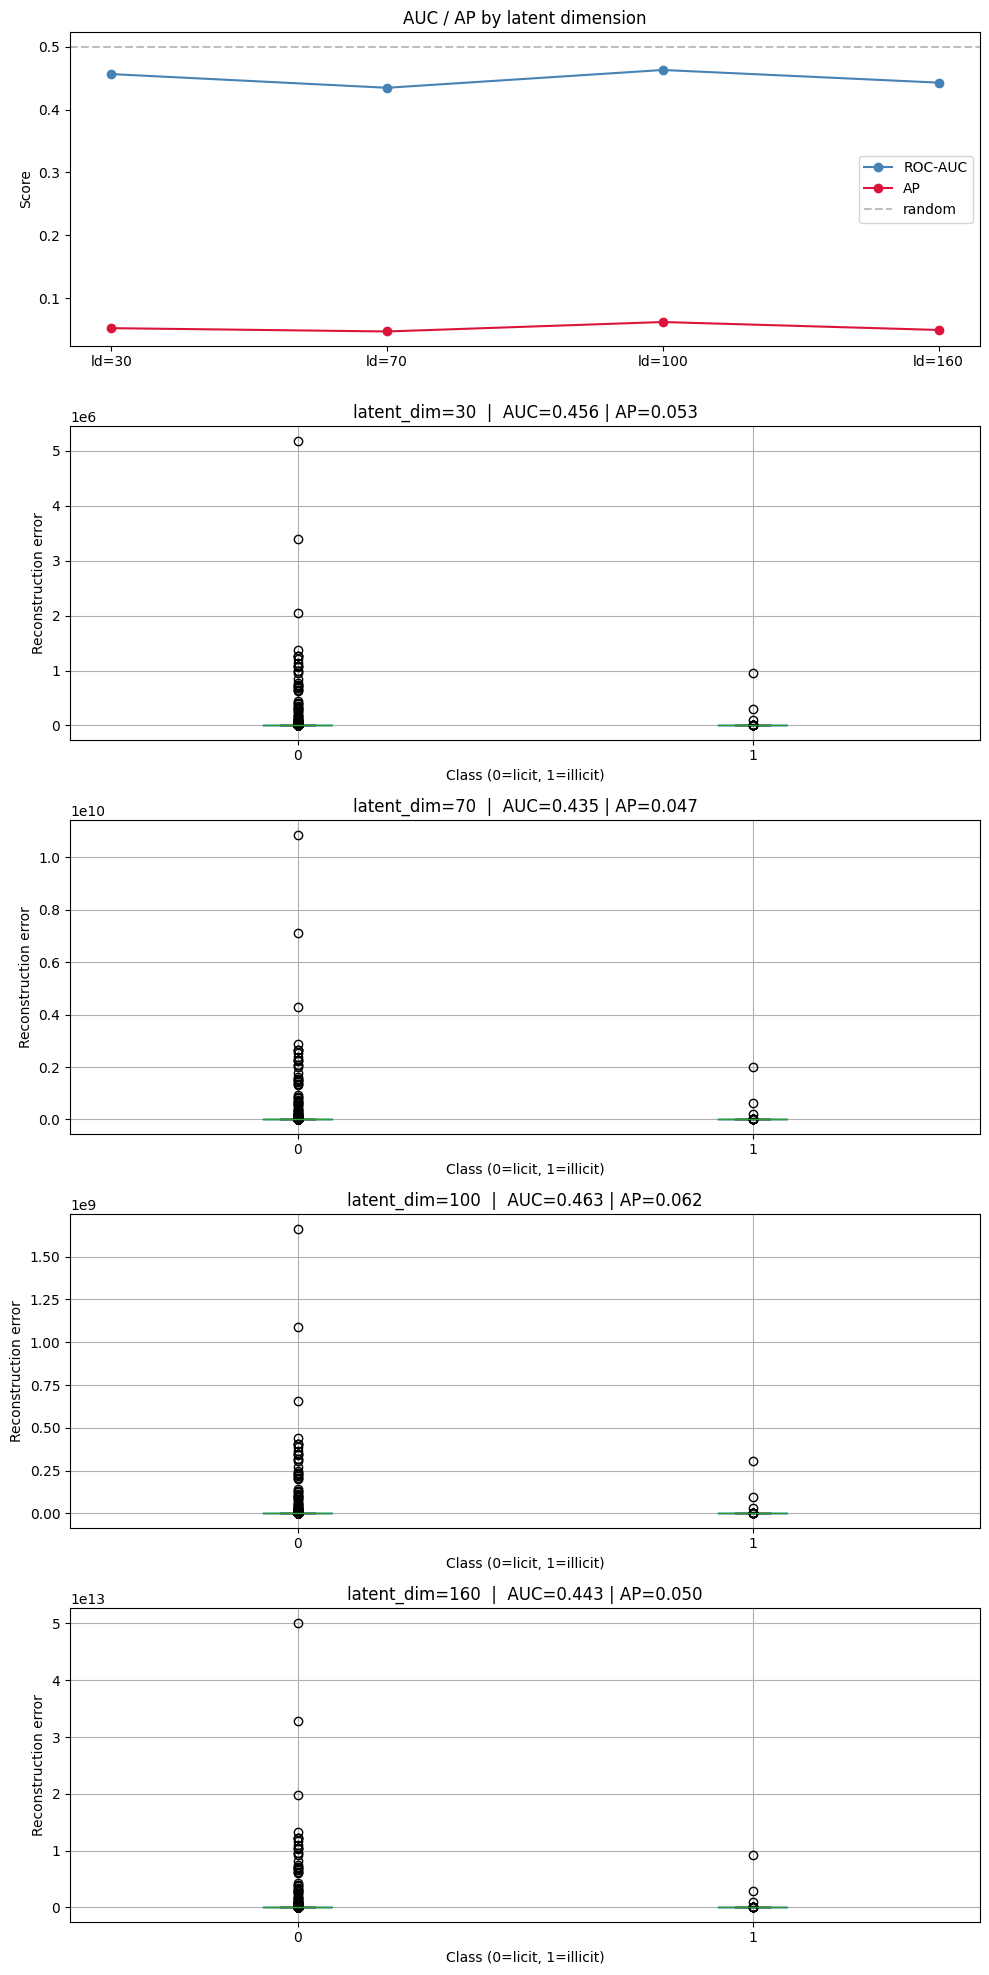

({30: {'test_results':             txId  time_step class  anomaly_score
   0       12781680         41     0      10.547976
   1       39010634         41     2     171.076279
   2       12688678         41     0       0.579617
   3       12688662         41     2       0.329538
   4       12803377         41     2       0.233262
   ...          ...        ...   ...            ...
   42161  173077460         49     2     152.838104
   42162  158577750         49     2     148.023666
   42163  158375402         49     1       0.556628
   42164  158654197         49     2     155.132523
   42165  157597225         49     2     151.213989
   
   [42166 rows x 4 columns],
   'losses': [16213362747679.613,
    312774324899.07916,
    35035231033.92226,
    280381498542.4919,
    10950768423.576788,
    6817132510.520356,
    401818925813.7663,
    1284869936862.375,
    184082350833.89917,
    11651377482872.29,
    116910738971.00694,
    63711663483.98354,
    230145109159.57507,
    3223

In [68]:
ld = [30, 70, 100, 160]

results = {}
metrics = []
for dim in ld:
    print(f'dimensions: {dim}')

    model, losses, test_results, auc, ap = ae_orchestrator(
        e_train_df[enriched_cols],                                                               
        e_test_df[enriched_cols],
        e_test_df,
        feature_cols=feature_cols,
        graph_cols=graph_cols,
        hidden_dim=64, latent_dim=16, epochs=50
        ) 
    
    results[dim] = {'test_results': test_results, 'losses': losses}
    metrics.append({'latent_dim': dim, 'auc': auc, 'ap': ap})

metrics_df = pd.DataFrame(metrics)

plot_ae_latent_comparison(metrics_df, ld, results)

## Temporal Autoencoder

Rationale - 
  The static AE trains once on all licit transactions (t≤40) and scores the remainder.
  This assumes licit behavior is stationary — the same patterns persist across  all timesteps. As with the linear CF models, The temporal AE tests whether **adapting the model to evolving licit behavior** improves anomaly detection. At each timestep t, a new model is trained on all licit transactions seen so far (t' < t) and used to score only transactions at t.

**Architecture**
  Same 2-layer symmetric architecture as the static AE baseline, to isolate the effect
  of the temporal approach from architectural complexity:
  input → hidden → latent → hidden → input

  **Conditional conclusion**
  - If AUC improves significantly over static AE → temporal adaptation adds signal;
    concept drift in licit behavior is a meaningful factor
  - If AUC remains ≤ 0.5 → neither non-linearity nor temporal adaptation is sufficient;
    the reconstruction error paradigm is fundamentally limited on this dataset
    regardless of model complexity or training strategy


In [69]:
class Autoencoder2L(nn.Module):
      """2-layer symmetric autoencoder — baseline architecture for temporal experiment"""
      def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
          super().__init__()
          self.encoder = nn.Sequential(
              nn.Linear(input_dim, hidden_dim), nn.ReLU(),
              nn.Linear(hidden_dim, latent_dim), nn.ReLU()
          )
          self.decoder = nn.Sequential(
              nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
              nn.Linear(hidden_dim, input_dim)
          )
      def forward(self, x):
          return self.decoder(self.encoder(x))


def train_autoencoder_2l(X_train, hidden_dim=64, latent_dim=16,
                        epochs=30, batch_size=256, lr=1e-3):
    model = Autoencoder2L(X_train.shape[1], hidden_dim, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_train)),
                        batch_size=batch_size, shuffle=True)
    model.train()
    for _ in range(epochs):
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
    return model


In [72]:
def temporal_autoencoder(df, feature_cols,
                            latent_dim=16, hidden_dim=64,
                            epochs=30, batch_size=256, lr=1e-3):
      all_results = []
      min_train   = latent_dim * 10   # guard: need enough samples to fit rank components

      for t in sorted(df['time_step'].unique()):
          train = df[(df['class'] == 0) & (df['time_step'] < t)]
          test  = df[df['time_step'] == t]

          if len(train) < min_train:
              continue

          X_train = np.array(train[feature_cols])
          X_test  = np.array(test[feature_cols])

          scaler    = StandardScaler()
          X_train_s = scaler.fit_transform(X_train)
          X_test_s  = scaler.transform(X_test)

          model  = train_autoencoder_2l(X_train_s, hidden_dim=hidden_dim,
                                         latent_dim=latent_dim,
                                         epochs=epochs, batch_size=batch_size, lr=lr)
          errors = score_autoencoder(model, X_test_s)

          all_results.append(pd.DataFrame({
              'txId':          test['txId'].values,
              'time_step':     t,
              'class':         test['class'].values,
              'anomaly_score': errors
          }))

      return pd.concat(all_results, ignore_index=True)


In [71]:
def plot_temporal_errors(all_results):
    labeled = all_results[all_results['class'] < 2]

    # mean + std per class per timestep
    stats = labeled.groupby(['time_step', 'class'])['anomaly_score'].agg(['mean', 'std']).reset_index()
  
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
                
    colors = {0: 'steelblue', 1: 'crimson'}
    labels = {0: 'Licit', 1: 'Illicit'}

    # top: mean error per class with std band
    for cls in [0, 1]:
        d = stats[stats['class'] == cls]
        ax1.plot(d['time_step'], d['mean'], color=colors[cls], label=labels[cls])
        ax1.fill_between(d['time_step'],
                        d['mean'] - d['std'],
                        d['mean'] + d['std'],
                        alpha=0.2, color=colors[cls])
    ax1.set_ylabel('Mean reconstruction error')
    ax1.legend()
    ax1.axvline(x=35, color='gray', linestyle='--', alpha=0.5, label='train cutoff')

    # bottom: gap (illicit - licit) — positive = model detects fraud
    licit   = stats[stats['class'] == 0].set_index('time_step')['mean']
    illicit = stats[stats['class'] == 1].set_index('time_step')['mean']
    gap = illicit - licit
    ax2.bar(gap.index, gap.values, color=gap.apply(lambda x: 'crimson' if x > 0 else 'steelblue'))
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('Error gap (illicit − licit)')
    ax2.set_xlabel('Time step')

    plt.tight_layout()
    plt.show()


In [ ]:
temporal_results = temporal_autoencoder(
      enriched_df, enriched_cols,                   
      latent_dim=100, hidden_dim=64, epochs=30
  )                                                                                         
   

Temporal AE — ROC-AUC: 0.2822 | AP: 0.0664
         count      mean        std       min       25%       50%       75%  \
class                                                                         
0      39889.0  0.460616  13.534146  0.002952  0.038492  0.075314  0.154290   
1       4528.0  0.189467   2.280761  0.003212  0.021220  0.034751  0.061547   

               max  
class               
0      1692.055664  
1        89.075790  


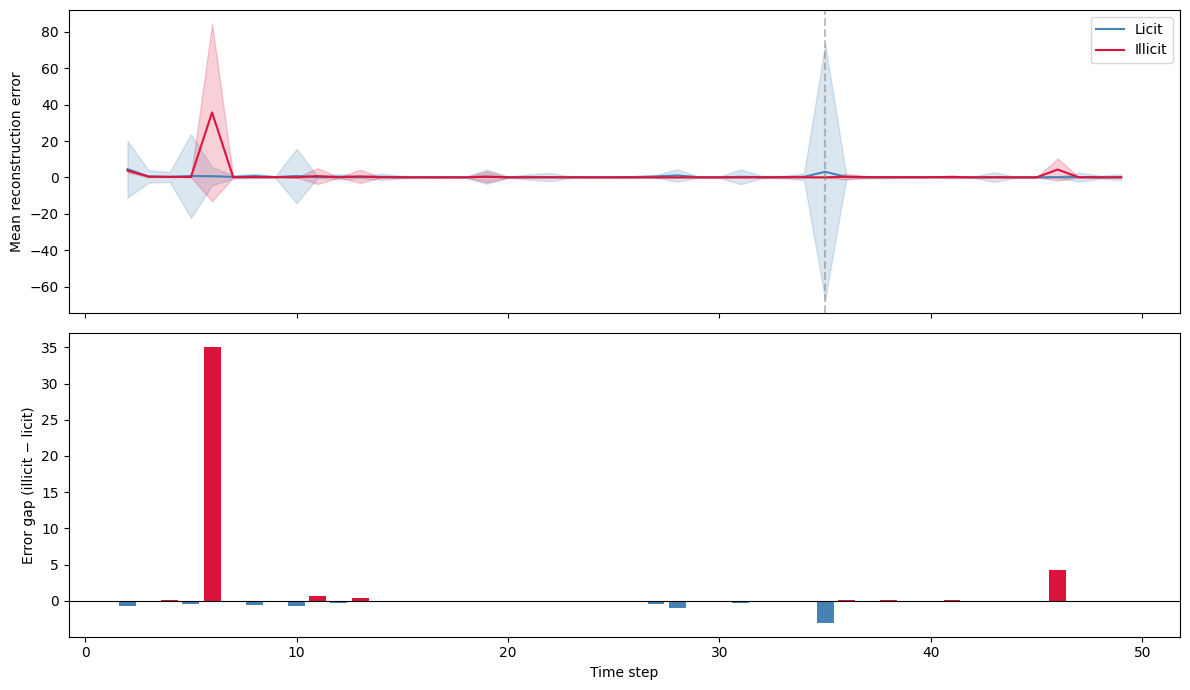

In [75]:
labeled = temporal_results[temporal_results['class'] < 2]                                 
auc = roc_auc_score(labeled['class'].astype(int), labeled['anomaly_score'])                           
ap  = average_precision_score(labeled['class'].astype(int), labeled['anomaly_score'])
print(f'Temporal AE — ROC-AUC: {auc:.4f} | AP: {ap:.4f}')                                 
print(labeled.groupby('class')['anomaly_score'].describe())
                                                                                        
# reuse temporal error plot from NMF experiment                                           
plot_temporal_errors(temporal_results) 

# Invertability

"Standard reconstruction-based anomaly detection assumes anomalies are out-of-distribution. The consistent inversion observed across all methods reveals a secondary property of the Elliptic dataset: illicit transactions exhibit behavioral stereotypy — they are systematically more homogeneous than licit ones, reconstructing with lower error. Under an inverted detection paradigm, validated on a held-out period, this stereotypy becomes the detection signal."


In [81]:
def ae_inverted_orchestrator(df, feature_cols,                                            
                            train_ts=range(1,31),                                       
                            val_ts=range(31,41),                                        
                            test_ts=range(41,50),                                       
                            hidden_dim=64, latent_dim=16,                               
                            epochs=50, batch_size=256, lr=1e-3):                        

    train_df = df[(df['time_step'].isin(train_ts)) & (df['class'] == 0)]                  
    val_df   = df[df['time_step'].isin(val_ts)]
    test_df  = df[df['time_step'].isin(test_ts)]                                          
                
    X_train = np.array(train_df[feature_cols])                                            
    scaler  = StandardScaler().fit(X_train)
                                                                                        
    X_train_s = scaler.transform(X_train)
    X_val_s   = scaler.transform(np.array(val_df[feature_cols]))
    X_test_s  = scaler.transform(np.array(test_df[feature_cols]))                         

    model = train_autoencoder_2l(X_train_s, hidden_dim=hidden_dim,                        
                                latent_dim=latent_dim, epochs=epochs,
                                batch_size=batch_size, lr=lr) 
    # validation: confirm inversion direction                                             
    val_errors  = score_autoencoder(model, X_val_s)
    val_labeled = val_df[val_df['class'] < 2].copy()                                      
    val_labeled['anomaly_score'] = val_errors[val_df['class'] < 2]                        

    # generate inverted auc                                                                                
    auc_standard = roc_auc_score(val_labeled['class'].astype(int),  val_labeled['anomaly_score'])     
    auc_inverted = roc_auc_score(val_labeled['class'].astype(int), -val_labeled['anomaly_score'])

    
    direction = -1 if auc_inverted > auc_standard else 1                                  
    print(f'Validation — standard AUC: {auc_standard:.3f} | '
        f'inverted AUC: {auc_inverted:.3f} | using: {"inverted" if direction==-1 else "standard"}')                                                                             
                                                                                            
    # test with validated direction                                                       
    test_errors  = score_autoencoder(model, X_test_s)
    test_labeled = test_df[test_df['class'] < 2].copy()                                   
    test_labeled['anomaly_score'] = direction * test_errors[test_df['class'] < 2]
                                                                                        
    auc = roc_auc_score(test_labeled['class'].astype(int), test_labeled['anomaly_score'])             
    ap  = average_precision_score(test_labeled['class'].astype(int), test_labeled['anomaly_score'])   
    print(f'Test     — ROC-AUC: {auc:.4f} | AP: {ap:.4f}')                                
    print(test_labeled.groupby('class')['anomaly_score'].describe())                      
                                                                                        
    return model, test_labeled, auc, ap 

dimensions: 30
Validation — standard AUC: 0.253 | inverted AUC: 0.747 | using: inverted
Test     — ROC-AUC: 0.6885 | AP: 0.1559
        count      mean       std         min       25%       50%       75%  \
class                                                                         
0      9449.0 -0.892867  5.156142 -349.605164 -0.477435 -0.230193 -0.130978   
1       524.0 -0.617449  7.081252 -161.479919 -0.191496 -0.137440 -0.095926   

            max  
class            
0     -0.027202  
1     -0.023658  
dimensions: 100
Validation — standard AUC: 0.206 | inverted AUC: 0.794 | using: inverted
Test     — ROC-AUC: 0.7332 | AP: 0.2112
        count      mean       std         min       25%       50%       75%  \
class                                                                         
0      9449.0 -0.870903  4.755116 -330.332916 -0.493043 -0.259445 -0.154865   
1       524.0 -0.594332  6.695517 -152.674164 -0.216281 -0.131202 -0.093520   

            max  
class            
0

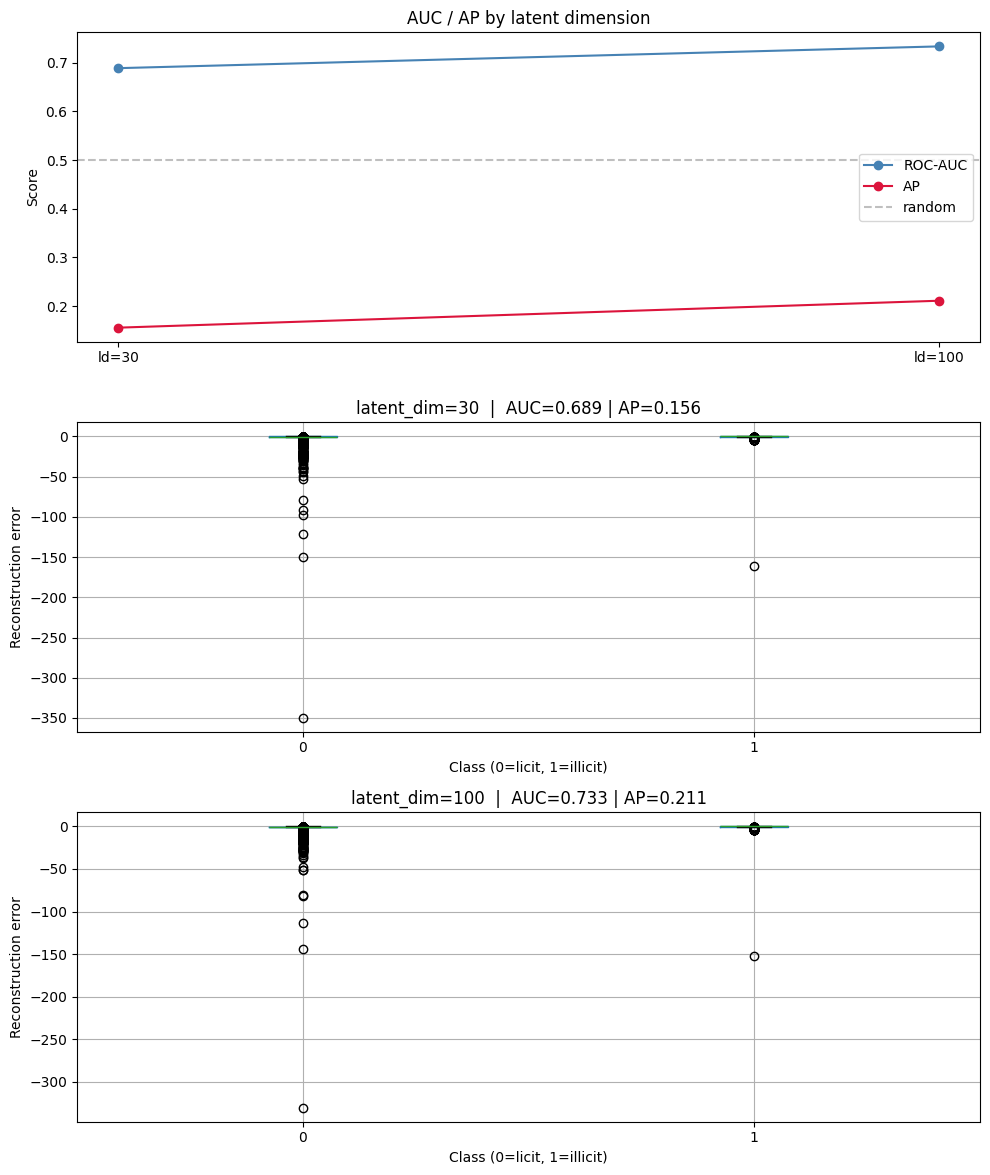

({30: {'test_results':              txId  time_step      lf_1      lf_2      lf_3      lf_4  \
   161603   12781680         41  2.740423  2.523310  2.128587 -0.046932   
   161605   12688678         41 -0.172918  0.016050  1.018602 -0.121970   
   161608   12805689         41  0.081972  6.441913  2.128587  3.855018   
   161609   13284351         41 -0.170928  0.335420  1.573595  0.103143   
   161610   13425520         41 -0.172689  0.456181  1.573595  0.178180   
   ...           ...        ...       ...       ...       ...       ...   
   203752   80329479         49 -0.159293 -0.037276  1.018602 -0.121970   
   203754  158406298         49 -0.172962 -0.126566  1.018602 -0.121970   
   203759  158375075         49 -0.170412 -0.078164  1.018602  0.028105   
   203763  147478192         49 -0.093732 -0.116160  1.018602 -0.121970   
   203766  158375402         49 -0.172014 -0.078182  1.018602  0.028105   
   
               lf_5      lf_6      lf_7      lf_8  ...     af_65     af_66  

In [83]:
ld = [30,  100]

results = {}
metrics = []
for dim in ld:
    print(f'dimensions: {dim}')

    model, test_results, auc, ap = ae_inverted_orchestrator(
        df, feature_cols=feature_cols,       
        ) 
    
    results[dim] = {'test_results': test_results, 'losses': losses}
    metrics.append({'latent_dim': dim, 'auc': auc, 'ap': ap})

metrics_df = pd.DataFrame(metrics)

plot_ae_latent_comparison(metrics_df, ld, results)